In [9]:
from loaders import load_tisch, load_sept, load_bible, load_references
import numpy as np
import pandas as pd

In [10]:
bible = load_bible()
bible.index = np.arange(len(bible))
references = load_references()

In [11]:
bible_books = bible["book"].unique()
book_map = pd.Series(np.arange(1, len(bible_books) + 1), index=bible_books)
bible["booknum"] = book_map[bible["book"]].values

In [12]:
bible["reference_text"] = False

for ostart, oend, nstart, nend in references[
    ["ostart", "oend", "nstart", "nend"]
].values:
    bible.loc[ostart : oend - 1, "reference_text"] = True
    bible.loc[nstart : nend - 1, "reference_text"] = True

In [13]:
ot = bible.query("booknum < 40")
nt = bible.query("booknum >= 40")
ot_books = ot["book"].unique()
nt_books = nt["book"].unique()

In [14]:
references["obook"] = bible.iloc[references["ostart"]]["book"].values
references["nbook"] = bible.iloc[references["nstart"]]["book"].values

In [15]:
use_counts = (
    references.groupby("nbook")
    .apply(
        lambda subreferences: subreferences.groupby("obook")["nlen"].sum(),
        include_groups=False,
    )
    .unstack()
    .reindex(nt_books, columns=ot_books)
    .fillna(0)
    .astype(int)
)
use_counts["total"] = nt.groupby("book")["reference_text"].sum()
use_counts["len"] = nt["book"].value_counts()

In [16]:
import seaborn as sns
sns.set_theme(style='white')

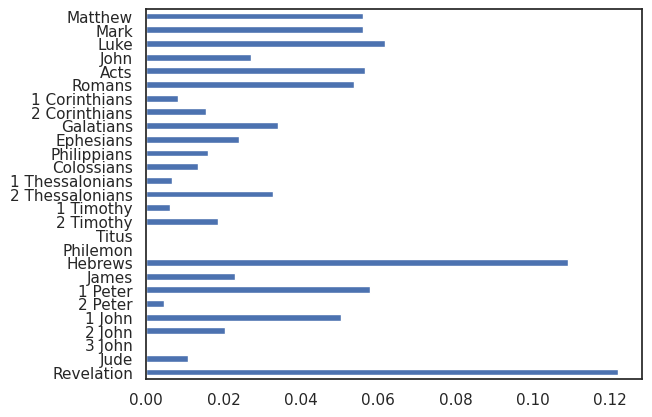

In [17]:
use_props = use_counts.drop(columns='len') / use_counts['len'].values[:, None]
use_props['total'][::-1].plot.barh(ylabel='');
#use_props.drop(columns='total', inplace=True)

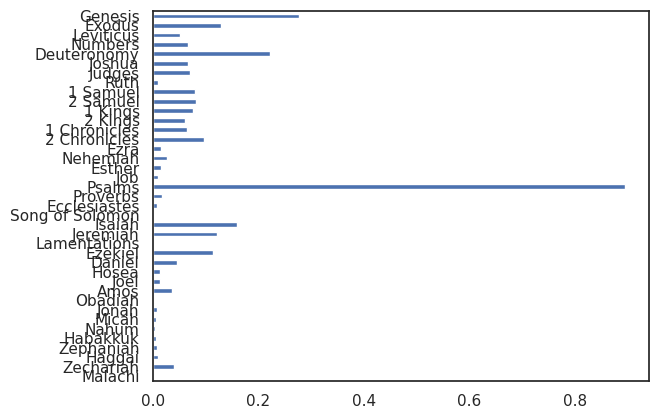

In [18]:
use_props.drop(columns='total').T.sum(axis=1)[::-1].plot.barh(ylabel='');

In [19]:
from sklearn.decomposition import PCA

use_props.drop(columns='total', inplace=True)
pca = PCA(n_components=2)

In [21]:
import matplotlib.pyplot as plt

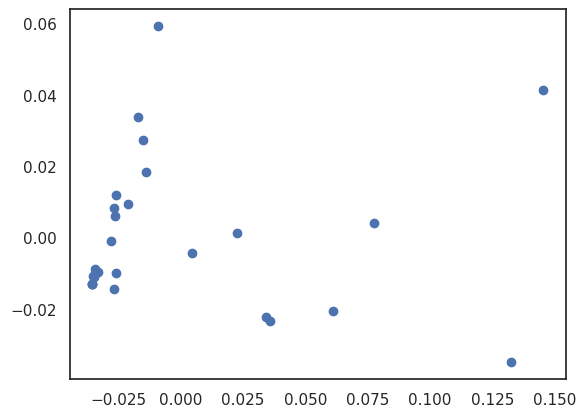

In [22]:
new_comps = pca.fit_transform(use_props)
# annotate the ith point with use_props.index[i]
plt.scatter(new_comps[:, 0], new_comps[:, 1])

In [38]:
nt['book'].unique()

array(['Matthew', 'Mark', 'Luke', 'John', 'Acts', 'Romans',
       '1 Corinthians', '2 Corinthians', 'Galatians', 'Ephesians',
       'Philippians', 'Colossians', '1 Thessalonians', '2 Thessalonians',
       '1 Timothy', '2 Timothy', 'Titus', 'Philemon', 'Hebrews', 'James',
       '1 Peter', '2 Peter', '1 John', '2 John', '3 John', 'Jude',
       'Revelation'], dtype=object)

In [43]:
new_df = pd.DataFrame(data=new_comps)
new_df['book'] = nt['book'].unique()
new_df = new_df[['book', 0, 1]]
new_df

,book,0,1
0,Matthew,-0.016974,0.033728
1,Mark,-0.014966,0.027345
2,Luke,-0.008884,0.059303
3,John,-0.021112,0.009412
4,Acts,-0.013764,0.018285
5,Romans,0.004703,-0.004248
6,1 Corinthians,-0.033260,-0.009621
7,2 Corinthians,-0.026067,-0.009828
8,Galatians,0.022536,0.001273
9,Ephesians,-0.026851,0.008292


In [45]:
px.scatter(
    new_df,
    x = 0,
    y = 1, 
    text = 'book'
)